In [1]:
import torch, torch_geometric

device = torch.device("mps" if torch.backends.mps.is_available() else print("CPU"))

/Users/krishpatel/code/VSC/HOMO_LUMO_Prediction/gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import time
from collections import Counter

import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

from torch_geometric.datasets import QM9
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing, global_mean_pool, global_add_pool

torch.manual_seed(0)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("torch:", torch.__version__)
print("device:", device)

torch: 2.13.0
device: mps


In [3]:
torch.manual_seed(0)
a = torch.randn(3)
b = torch.randn(3)
print("a first: ", a.tolist())
print("b second:", b.tolist())

torch.manual_seed(0)
b2 = torch.randn(3)
a2 = torch.randn(3)
print("b first: ", b2.tolist())
print("a second:", a2.tolist())

a first:  [1.5409960746765137, -0.293428897857666, -2.1787893772125244]
b second: [0.5684312582015991, -1.0845223665237427, -1.3985954523086548]
b first:  [1.5409960746765137, -0.293428897857666, -2.1787893772125244]
a second: [0.5684312582015991, -1.0845223665237427, -1.3985954523086548]


In [4]:
import sys
print(sys.executable)

/Users/krishpatel/code/VSC/HOMO_LUMO_Prediction/gnn/bin/python


In [5]:
#loading the QM9 dataset (to only utilize row 4) and verifying the number of molecules and the target vector per molecule
dataset = QM9(root='data/QM9')

print(dataset)
print("molecules:", len(dataset))
print("target vector per molecule:", tuple(dataset[0].y.shape))

QM9(130831)
molecules: 130831
target vector per molecule: (1, 19)


In [6]:
#verifying that row 4 is row 3-2 (homo-lumo eV size)

TARGET = 4
ATOM_TYPES = ["H", "C", "N", "O", "F"]
BOND_TYPES = ["single", "double", "triple", "aromatic"]

y = dataset[0].y[0]
print("HOMO:", round(y[2].item(), 4), "eV")
print("LUMO:", round(y[3].item(), 4), "eV")
print("gap :", round(y[4].item(), 4), "eV")
print("LUMO - HOMO =", round((y[3] - y[2]).item(), 4), "eV")

HOMO: -10.5499 eV
LUMO: 3.1865 eV
gap : 13.7363 eV
LUMO - HOMO = 13.7363 eV


In [7]:
mol = dataset[100]
print(mol)

Data(x=[11, 11], edge_index=[2, 22], edge_attr=[22, 4], y=[1, 19], pos=[11, 3], idx=[1], name='gdb_104', z=[11])


In [8]:
#converting edges and nodes graph to atoms and chemical bond representation based on formula
symbols = [ATOM_TYPES[int(row.argmax())] for row in mol.x[:, :5]]

counts = Counter(symbols)
formula = "".join(el + str(counts[el]) for el in ["C", "H", "N", "O", "F"] if counts[el])
print("formula:", formula)
print("atoms  :", symbols)
print()

print("bonds:")
seen = set()
for e in range(mol.edge_index.size(1)):
    i = int(mol.edge_index[0, e])
    j = int(mol.edge_index[1, e])
    if (j, i) in seen:
        continue
    seen.add((i, j))
    order = BOND_TYPES[int(mol.edge_attr[e].argmax())]
    print("  " + symbols[i] + str(i) + " -- " + symbols[j] + str(j) + "   " + order)

formula: C3H6O2
atoms  : ['O', 'C', 'C', 'C', 'O', 'H', 'H', 'H', 'H', 'H', 'H']

bonds:
  O0 -- C1   single
  O0 -- H5   single
  C1 -- C2   single
  C1 -- C3   single
  C1 -- H6   single
  C2 -- C3   single
  C2 -- H7   single
  C2 -- H8   single
  C3 -- O4   single
  C3 -- H9   single
  O4 -- H10   single


In [9]:
print("gap:", round(mol.y[0][4].item(), 3), "eV")

gap: 8.193 eV


In [10]:
#concatenate into one list for easy access: batches of 4 molecules
demo = DataLoader(dataset[:4], batch_size=4)
b = next(iter(demo))

print(b)
print()
print("atoms in each molecule:", [dataset[i].num_nodes for i in range(4)])
print("total rows in b.x     :", b.x.shape[0])
print()
print("b.batch:", b.batch.tolist())

DataBatch(x=[16, 11], edge_index=[2, 24], edge_attr=[24, 4], y=[4, 19], pos=[16, 3], idx=[4], name=[4], z=[16], batch=[16], ptr=[5])

atoms in each molecule: [5, 4, 3, 4]
total rows in b.x     : 16

b.batch: [0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 3, 3, 3, 3]


In [11]:
# Print each molecule's bonds twice: once as stored alone, once as stored in the
# batch. The numbers should be identical except shifted by the offset printed
# above them. This confirms molecules stay separate when merged.

offset = 0
for k in range(4):
    m = dataset[k]
    belongs = b.batch[b.edge_index[0]] == k   # picks out molecule k's bonds
    print("molecule", k, "-", m.num_nodes, "atoms, indices shifted by", offset)
    print("   stored alone   :", m.edge_index[:, :4].tolist())
    print("   inside the batch:", b.edge_index[:, belongs][:, :4].tolist())
    offset += m.num_nodes
    print()

molecule 0 - 5 atoms, indices shifted by 0
   stored alone   : [[0, 0, 0, 0], [1, 2, 3, 4]]
   inside the batch: [[0, 0, 0, 0], [1, 2, 3, 4]]

molecule 1 - 4 atoms, indices shifted by 5
   stored alone   : [[0, 0, 0, 1], [1, 2, 3, 0]]
   inside the batch: [[5, 5, 5, 6], [6, 7, 8, 5]]

molecule 2 - 3 atoms, indices shifted by 9
   stored alone   : [[0, 0, 1, 2], [1, 2, 0, 0]]
   inside the batch: [[9, 9, 10, 11], [10, 11, 9, 9]]

molecule 3 - 4 atoms, indices shifted by 12
   stored alone   : [[0, 0, 1, 1], [1, 3, 0, 2]]
   inside the batch: [[12, 12, 13, 13], [13, 15, 12, 14]]



In [12]:
for k in range(4):
    m = dataset[k]
    print(k, [ATOM_TYPES[int(r.argmax())] for r in m.x[:, :5]])

0 ['C', 'H', 'H', 'H', 'H']
1 ['N', 'H', 'H', 'H']
2 ['O', 'H', 'H']
3 ['C', 'C', 'H', 'H']


In [13]:
torch.manual_seed(0)

D = 4                       # length of each atom's vector, small enough to read
toy = dataset[100]
h = torch.randn(toy.num_nodes, D)

msg_fn = nn.Linear(2 * D + 4, D)

with torch.no_grad():
    agg = torch.zeros(toy.num_nodes, D)

    for e in range(toy.edge_index.size(1)):
        sender   = int(toy.edge_index[0, e])
        receiver = int(toy.edge_index[1, e])
        inputs = torch.cat([h[receiver], h[sender], toy.edge_attr[e]])
        agg[receiver] += msg_fn(inputs)

print(agg)

tensor([[ 0.0108, -1.2753,  0.5062, -0.0871],
        [ 0.9694, -1.8198,  1.9722,  1.4904],
        [-0.0382, -1.4452,  0.1383, -0.8369],
        [ 0.4584,  1.6607,  0.4172, -1.5058],
        [-0.3594, -1.8981,  0.2980, -1.5863],
        [ 0.1126,  0.1528, -0.0500, -0.8093],
        [ 0.2032, -0.0288, -0.2249,  0.5362],
        [ 0.0654,  0.2417,  0.3367, -0.6870],
        [ 0.1332,  0.5064,  0.2698, -0.6399],
        [ 0.4488, -0.5498, -0.1913,  0.0261],
        [ 0.1354,  1.3722, -0.1792, -1.8587]])


In [14]:
# Instead of processing one
# bond at a time, build all 22 messages at once and add them into agg in one call.
# the two methods give identical results.

with torch.no_grad():
    src = toy.edge_index[0]
    dst = toy.edge_index[1]

    inputs = torch.cat([h[dst], h[src], toy.edge_attr], dim=1)   # [22, 12]
    messages = msg_fn(inputs)                                     # [22, 4]
    agg_fast = torch.zeros(toy.num_nodes, D).index_add_(0, dst, messages)

print("matches the loop:", torch.allclose(agg, agg_fast, atol=1e-5))
print("largest difference: %.2e" % (agg - agg_fast).abs().max())

matches the loop: True
largest difference: 0.00e+00


In [15]:
# Wrap one round of message passing into a reusable class. PyG's MessagePassing
# base class handles the row-picking and row-adding you just did by hand; you
# only write the message function and the update.

class BondMessagePassing(MessagePassing):
    def __init__(self, hidden, edge_dim):
        super().__init__(aggr="add")
        self.message_mlp = nn.Sequential(
            nn.Linear(2 * hidden + edge_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(2 * hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
        )

    def forward(self, x, edge_index, edge_attr):
        aggregated = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        return x + self.update_mlp(torch.cat([x, aggregated], dim=-1))

    def message(self, x_i, x_j, edge_attr):
        return self.message_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

In [16]:
# Check the class does the same thing as your loop. Runs the class once, then
# does the same computation by hand, and compares.

HIDDEN, EDGE_DIM = 8, 4
layer = BondMessagePassing(HIDDEN, EDGE_DIM)
hh = torch.randn(toy.num_nodes, HIDDEN)

with torch.no_grad():
    out_pyg = layer(hh, toy.edge_index, toy.edge_attr)

    src, dst = toy.edge_index
    m = layer.message_mlp(torch.cat([hh[dst], hh[src], toy.edge_attr], dim=1))
    agg = torch.zeros_like(hh).index_add_(0, dst, m)
    out_manual = hh + layer.update_mlp(torch.cat([hh, agg], dim=1))

print("class matches by-hand version:", torch.allclose(out_pyg, out_manual, atol=1e-5))

class matches by-hand version: True


In [17]:
# The full model. Widens 11 atom features to 128, runs 4 rounds of message
# passing, averages all atoms into one vector per molecule, then converts that
# to a single number.

NODE_DIM = 11
EDGE_DIM = 4
HIDDEN = 128
LAYERS = 4


class GapNet(nn.Module):
    def __init__(self, hidden=HIDDEN, layers=LAYERS):
        super().__init__()
        self.embed = nn.Linear(NODE_DIM, hidden)
        self.rounds = nn.ModuleList(
            BondMessagePassing(hidden, EDGE_DIM) for _ in range(layers)
        )
        self.head = nn.Sequential(
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 1)
        )

    def forward(self, data):
        x = self.embed(data.x)
        for round_ in self.rounds:
            x = round_(x, data.edge_index, data.edge_attr)
        molecule = global_mean_pool(x, data.batch)
        return self.head(molecule).squeeze(-1)

In [18]:
# Create the model and run one batch through it. Confirms it builds, prints how
# many trainable numbers it has, and checks the output is one value per molecule.

probe = GapNet()
print("parameters:", sum(p.numel() for p in probe.parameters()))

sample_batch = next(iter(DataLoader(dataset[:32], batch_size=32)))
with torch.no_grad():
    out = probe(sample_batch)

print("atoms in batch      :", sample_batch.x.shape[0])
print("molecules in batch  :", int(sample_batch.batch.max()) + 1)
print("predictions returned:", tuple(out.shape))

parameters: 415489
atoms in batch      : 230
molecules in batch  : 32
predictions returned: (32,)


In [19]:
# Renumber one molecule's atoms and check the prediction doesn't change.
# The whole architecture was designed so atom numbering can't matter.

def relabel(d, perm):
    inverse = torch.empty_like(perm)
    inverse[perm] = torch.arange(d.num_nodes)
    return Data(x=d.x[perm], edge_index=inverse[d.edge_index],
                edge_attr=d.edge_attr, y=d.y)


probe.eval()
perm = torch.randperm(toy.num_nodes)

with torch.no_grad():
    original   = probe(Batch.from_data_list([toy])).item()
    relabelled = probe(Batch.from_data_list([relabel(toy, perm)])).item()

print("original numbering :", round(original, 6))
print("shuffled numbering :", round(relabelled, 6))
print("difference         : %.2e" % abs(original - relabelled))

original numbering : 0.118769
shuffled numbering : 0.118769
difference         : 2.98e-08


In [20]:
# Shuffle the molecules once, then cut into test / validation / train.
# SUBSET=5000 keeps this fast while you're learning. Set to None for the full run.

SEED = 0
SUBSET = None

work = dataset if SUBSET is None else dataset[:SUBSET]

perm = torch.randperm(len(work), generator=torch.Generator().manual_seed(SEED))
work = work[perm]

n_test = max(1, len(work) // 13)
test_set  = work[:n_test]
val_set   = work[n_test:2 * n_test]
train_set = work[2 * n_test:]

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=256)
test_loader  = DataLoader(test_set, batch_size=256)

print("train %d   val %d   test %d" % (len(train_set), len(val_set), len(test_set)))

train 110705   val 10063   test 10063


In [21]:
# Compute the average and spread of the gap across TRAINING molecules only.
# The model will predict in these standardized units, then convert back to eV.

train_y = torch.cat([b.y[:, TARGET] for b in DataLoader(train_set, batch_size=2048)])
y_mean = train_y.mean().to(device)
y_std = train_y.std().to(device)

print("training mean %.4f eV   std %.4f eV" % (y_mean, y_std))
print("baseline MAE (always predict the mean): %.4f eV"
      % (train_y - train_y.mean()).abs().mean())

training mean 6.8571 eV   std 1.2833 eV
baseline MAE (always predict the mean): 1.0737 eV


In [22]:
# Create the model, the optimizer, and a function that runs one full pass over a
# dataset. run_epoch handles both training and evaluation via the train flag.

model = GapNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #mechanism to adjust desired weights in each pass
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau( #slows the learning rate if the validation loss doesn't improve for 5 epochs
    optimizer, mode="min", factor=0.7, patience=5, min_lr=1e-5
)


def run_epoch(loader, train):
    model.train() if train else model.eval()
    total_error, total_count = 0.0, 0

    for data in loader:
        data = data.to(device)
        truth = data.y[:, TARGET]

        with torch.set_grad_enabled(train):
            pred = model(data) * y_std + y_mean 
            loss = F.l1_loss(pred, truth) # computing loss function value

        if train:
            optimizer.zero_grad() #clear previous adjustment
            loss.backward() #backprop, deciding how to adjust weights based on loss
            optimizer.step() # actually moving them

        total_error += loss.item() * truth.numel()
        total_count += truth.numel()

    return total_error / total_count

In [23]:
# Time one epoch before committing to a full run. Multiply this by your epoch
# count to see how long training will take.

t0 = time.time()
first = run_epoch(train_loader, train=True)
print("one epoch: %.0f s, train MAE %.4f eV" % (time.time() - t0, first))

one epoch: 59 s, train MAE 0.4333 eV


In [24]:
# Train for 60 epochs. Records train and validation error each epoch, and saves
# the best weights whenever validation improves.

EPOCHS = 100
history = []
best_val = float("inf")
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    train_mae = run_epoch(train_loader, train=True)
    val_mae = run_epoch(val_loader, train=False)
    scheduler.step(val_mae)
    history.append((train_mae, val_mae))

    if val_mae < best_val:
        best_val = val_mae
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, "best_model.pt")

    print("epoch %3d   train %.4f   val %.4f   best %.4f   lr %.1e   %3.0fs"
          % (epoch, train_mae, val_mae, best_val,
             optimizer.param_groups[0]["lr"], time.time() - t0))

epoch   1   train 0.2886   val 0.2729   best 0.2729   lr 1.0e-03    88s
epoch   2   train 0.2572   val 0.2415   best 0.2415   lr 1.0e-03   1177s
epoch   3   train 0.2377   val 0.2401   best 0.2401   lr 1.0e-03   175s
epoch   4   train 0.2271   val 0.2271   best 0.2271   lr 1.0e-03    38s
epoch   5   train 0.2154   val 0.2080   best 0.2080   lr 1.0e-03    37s
epoch   6   train 0.2081   val 0.2173   best 0.2080   lr 1.0e-03    35s
epoch   7   train 0.2014   val 0.2012   best 0.2012   lr 1.0e-03    36s
epoch   8   train 0.1954   val 0.1957   best 0.1957   lr 1.0e-03    35s
epoch   9   train 0.1900   val 0.1888   best 0.1888   lr 1.0e-03    38s
epoch  10   train 0.1843   val 0.1825   best 0.1825   lr 1.0e-03    35s
epoch  11   train 0.1802   val 0.1754   best 0.1754   lr 1.0e-03    34s
epoch  12   train 0.1761   val 0.1806   best 0.1754   lr 1.0e-03    31s
epoch  13   train 0.1724   val 0.1768   best 0.1754   lr 1.0e-03    31s
epoch  14   train 0.1704   val 0.1709   best 0.1709   lr 1.0e-0

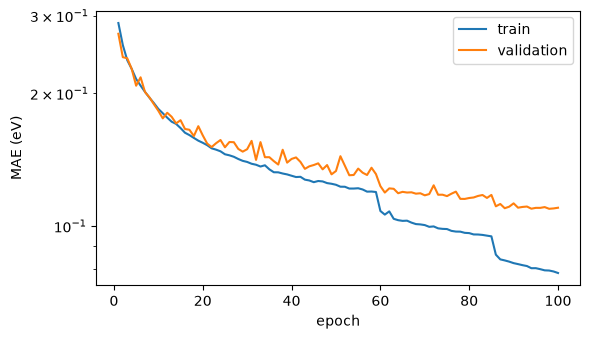

In [25]:
# Plot train and validation error against epoch. Log scale on the y-axis because
# the error spans a wide range and the late improvements matter.

tr = [h[0] for h in history]
va = [h[1] for h in history]

plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(tr) + 1), tr, label="train")
plt.plot(range(1, len(va) + 1), va, label="validation")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MAE (eV)")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Loading the best weights and evaluate on the test set. These 10,000 molecules have
# never been used for training or for any decision, making this a more honest number.

model.load_state_dict(best_state)
model.to(device).eval()

preds, truths = [], []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        preds.append((model(data) * y_std + y_mean).cpu())
        truths.append(data.y[:, TARGET].cpu())

preds = torch.cat(preds)
truths = torch.cat(truths)
errors = (preds - truths).abs()

print("test MAE        : %.4f eV" % errors.mean())
print("median error    : %.4f eV" % errors.median())
print("90th percentile : %.4f eV" % errors.quantile(0.90))
print("worst           : %.4f eV" % errors.max())
print()
print("baseline (predict the mean): %.4f eV" % (truths - truths.mean()).abs().mean())

test MAE        : 0.1099 eV
median error    : 0.0747 eV
90th percentile : 0.2472 eV
worst           : 1.9862 eV

baseline (predict the mean): 1.0783 eV


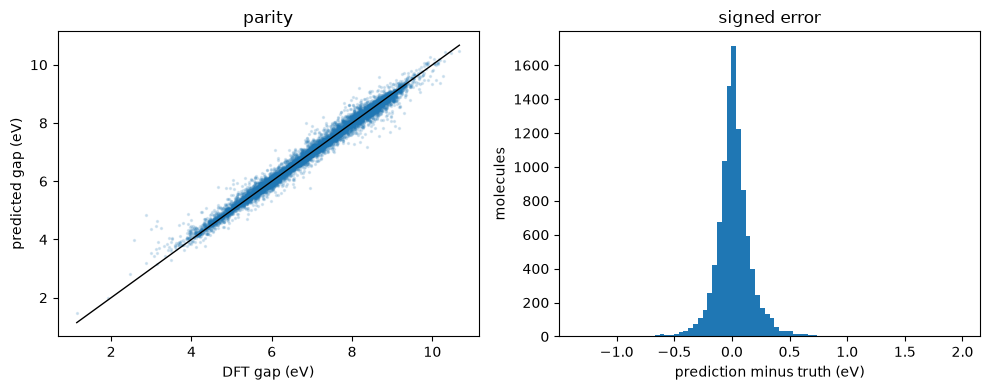

In [27]:
# Two plots. Left: predicted vs true gap, with a diagonal line showing perfect
# prediction. Right: how the errors are distributed, including their sign.

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

lo = float(min(truths.min(), preds.min()))
hi = float(max(truths.max(), preds.max()))
ax[0].scatter(truths.numpy(), preds.numpy(), s=2, alpha=0.15)
ax[0].plot([lo, hi], [lo, hi], linewidth=1, color="black")
ax[0].set_xlabel("DFT gap (eV)")
ax[0].set_ylabel("predicted gap (eV)")
ax[0].set_title("parity")

ax[1].hist((preds - truths).numpy(), bins=80)
ax[1].set_xlabel("prediction minus truth (eV)")
ax[1].set_ylabel("molecules")
ax[1].set_title("signed error")

plt.tight_layout()
plt.show()